<a href="https://colab.research.google.com/github/Adeline187/Build_and_Deploy-ML/blob/main/EXPT4/Support_Vector_Machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Support Vector Machine (SVM) Binary Classification
### Dataset: Breast Cancer Wisconsin (Diagnostic)

This experiment demonstrates a complete workflow for training a Support Vector Machine (SVM) classifier:
1. Loading and exploring the dataset
2. Stratified train-test splitting
3. Feature scaling using `StandardScaler`
4. Hyperparameter tuning using `GridSearchCV`
5. Training the final optimized model
6. Model evaluation using standard metrics (Accuracy, Precision, Recall, F1-Score, ROC-AUC)
7. Visualizing the ROC Curve

In [4]:
# 1. Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

## 2. Load and Inspect Dataset
We load the Breast Cancer dataset from `sklearn.datasets`.
* Target **0**: Malignant
* Target **1**: Benign

In [5]:
# Load Dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")   # 0 = Malignant, 1 = Benign

print("Dataset Shape:", X.shape)
print("\nFirst Five Rows:")
display(X.head())

print("\nTarget Distribution:")
print(y.value_counts())

Dataset Shape: (569, 30)

First Five Rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target Distribution:
target
1    357
0    212
Name: count, dtype: int64


## 3. Train-Test Split & Feature Scaling
* **Train-Test Split:** Perform an 80/20 train-test split stratified by target class labels.
* **Feature Scaling:** Apply `StandardScaler` to ensure features are on a similar scale (crucial for distance-based algorithms like SVM).

In [6]:
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Model Definition & Hyperparameter Tuning
Using `GridSearchCV` to optimize hyperparameters $C$ and $\gamma$ (gamma) using 5-fold cross-validation based on the F1-score.

In [7]:
# Define Base Model
svm = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

# Hyperparameter Grid
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.001, 0.0001]
}

# Grid Search CV
grid = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest Cross Validation Score:")
print(f"{grid.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Parameters:
{'C': 10, 'gamma': 0.01}

Best Cross Validation Score:
0.9844


## 5. Train Final Model & Evaluate
Fit the best estimator obtained from `GridSearchCV` on the training set and evaluate performance on the unseen test set.

In [8]:
# Train Final Model
best_svm = grid.best_estimator_
best_svm.fit(X_train_scaled, y_train)

# Predictions
y_pred = best_svm.predict(X_test_scaled)
y_prob = best_svm.predict_proba(X_test_scaled)[:, 1]

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

cm = confusion_matrix(y_test, y_pred)

print("\n==============================")
print("SVM (RBF) Test Performance")
print("==============================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nConfusion Matrix")
print(cm)

print("\nClassification Report")
print(classification_report(y_test, y_pred))


SVM (RBF) Test Performance
Accuracy  : 0.9825
Precision : 0.9861
Recall    : 0.9861
F1-Score  : 0.9861
ROC-AUC   : 0.9977

Confusion Matrix
[[41  1]
 [ 1 71]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 6. Plot ROC Curve
Visualize the Receiver Operating Characteristic (ROC) curve to analyze the true positive rate vs. false positive rate trade-off.

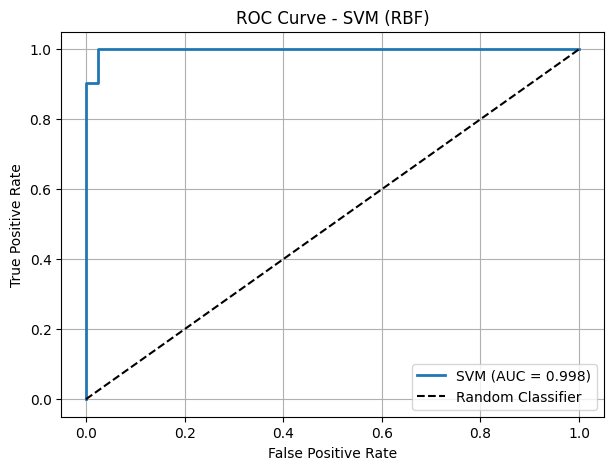

In [9]:
# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"SVM (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM (RBF)")
plt.legend()
plt.grid(True)

plt.show()